In [30]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
df = pd.read_csv("../data/raw/heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [36]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

[0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0
 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1]


In [37]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print("Accuracy:", accuracy)
print("ROC-AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8032786885245902
ROC-AUC: 0.8690476190476191

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Confusion Matrix:
[[19  9]
 [ 3 30]]


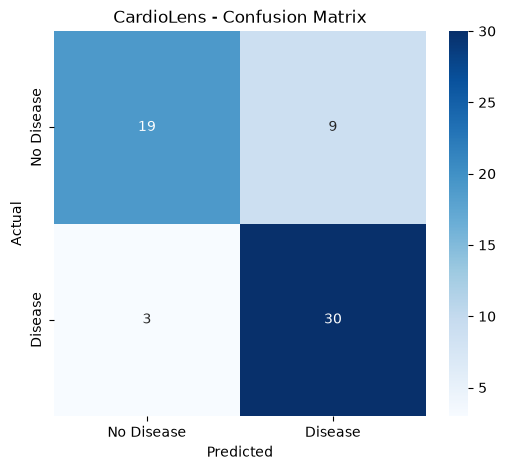

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CardioLens - Confusion Matrix")
plt.show()

In [39]:
joblib.dump(model, "../models/logistic_regression.pkl")

['../models/logistic_regression.pkl']

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

In [41]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.819672131147541
Random Forest ROC-AUC: 0.9042207792207793

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



In [42]:
joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [43]:
!pip install xgboost

In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print(classification_report(y_test, xgb_pred))

joblib.dump(xgb_model, "../models/xgboost.pkl")
print("XGBoost saved.")

XGBoost Accuracy: 0.7868852459016393
XGBoost ROC-AUC: 0.8712121212121212
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

XGBoost saved.


In [45]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("SVM ROC-AUC:", roc_auc_score(y_test, svm_prob))
print(classification_report(y_test, svm_pred))

joblib.dump(svm_model, "../models/svm.pkl")
print("SVM saved.")

SVM Accuracy: 0.819672131147541
SVM ROC-AUC: 0.8831168831168832
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

SVM saved.


c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("KNN ROC-AUC:", roc_auc_score(y_test, knn_prob))
print(classification_report(y_test, knn_pred))

joblib.dump(knn_model, "../models/knn.pkl")
print("KNN saved.")

KNN Accuracy: 0.819672131147541
KNN ROC-AUC: 0.8923160173160174
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

KNN saved.


In [47]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Best CV ROC-AUC:
0.8906112406112406


In [48]:
best_rf = grid_search.best_estimator_

tuned_rf_pred = best_rf.predict(X_test_scaled)
tuned_rf_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, tuned_rf_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, tuned_rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, tuned_rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_rf_pred))

Test Accuracy: 0.819672131147541
Test ROC-AUC: 0.9101731601731602

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61


Confusion Matrix:
[[19  9]
 [ 2 31]]


In [49]:
joblib.dump(best_rf, "../models/random_forest_tuned.pkl")

print("Tuned Random Forest saved.")

Tuned Random Forest saved.


In [50]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": model,
    "Random Forest": rf_model,
    "Tuned Random Forest": best_rf,
    "XGBoost": xgb_model,
    "SVM": svm_model,
    "KNN": knn_model
}

In [51]:
from sklearn.pipeline import Pipeline

cv_results = []

# Models that use scaled data
scaled_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Tuned Random Forest": best_rf,
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

for name, estimator in scaled_models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })


# XGBoost
xgb_scores = cross_validate(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
    n_jobs=-1
)

cv_results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_scores["test_accuracy"].mean(),
    "ROC-AUC": xgb_scores["test_roc_auc"].mean(),
    "Precision": xgb_scores["test_precision"].mean(),
    "Recall": xgb_scores["test_recall"].mean(),
    "F1": xgb_scores["test_f1"].mean()
})

In [52]:
results_df = pd.DataFrame(cv_results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.round(3)

,Model,Accuracy,ROC-AUC,Precision,Recall,F1
2,Tuned Random Forest,0.809,0.910,0.815,0.848,0.829
1,Random Forest,0.812,0.907,0.820,0.848,0.832
0,Logistic Regression,0.842,0.890,0.820,0.915,0.864
3,SVM,0.822,0.888,0.810,0.891,0.846
5,XGBoost,0.796,0.886,0.790,0.861,0.821
4,KNN,0.805,0.870,0.791,0.891,0.836


In [53]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Tuned Random Forest",
        "Random Forest",
        "Logistic Regression",
        "SVM",
        "XGBoost",
        "KNN"
    ],
    "Accuracy": [0.809, 0.812, 0.842, 0.822, 0.796, 0.805],
    "ROC-AUC": [0.910, 0.907, 0.890, 0.888, 0.886, 0.870],
    "Precision": [0.815, 0.820, 0.820, 0.810, 0.790, 0.791],
    "Recall": [0.848, 0.848, 0.915, 0.891, 0.861, 0.891],
    "F1": [0.829, 0.832, 0.864, 0.846, 0.821, 0.836]
})

results_df.to_csv("../models/model_comparison.csv", index=False)

results_df

,Model,Accuracy,ROC-AUC,Precision,Recall,F1
0,Tuned Random Forest,0.809,0.910,0.815,0.848,0.829
1,Random Forest,0.812,0.907,0.820,0.848,0.832
2,Logistic Regression,0.842,0.890,0.820,0.915,0.864
3,SVM,0.822,0.888,0.810,0.891,0.846
4,XGBoost,0.796,0.886,0.790,0.861,0.821
5,KNN,0.805,0.870,0.791,0.891,0.836
